# PS-S6E06: Model Blending


This notebook tackles the [**Playground Series – Season 6, Episode 6: Predicting Stellar Class**](https://www.kaggle.com/competitions/playground-series-s6e6), a competition focused on predicting a class label (`GALAXY`, `QSO`, `STAR`) for the `class` target, based on features describing the position, light intensity for various spectrums, and other features of the observation.

## Ensemble Strategy: Hill Climbing

We combine model outputs using a simple, effective hill-climbing ensemble (Caruana-style):

- Start from the best single model (highest OOF balanced accuracy)
- Iteratively add the model that improves the blended OOF balanced accuracy the most
- Convert selection counts into weights

We blend raw probabilities directly — no rank normalization. Each base model
(CatBoost, XGBoost, LightGBM, NN) was trained with class-balanced weighting and
outputs well-calibrated softmax/probability vectors, so a column-wise rank
transform would distort the within-row class ordering that argmax depends on
rather than improving comparability across models.

---


## Install Needed Packages

(Usually not needed on Kaggle; keep this section only if you add extra dependencies.)


In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from itertools import product

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

from ps_s06e06_experiment_setup import ExperimentSetup
from ps_s06e06_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')

%matplotlib inline


In [2]:
setup = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

# Target column in the training dataset
TARGET = 'class'

Random seed set to: 10301
Warnings suppressed.


In [3]:
# Load training data and ground truth
training_df = setup.read_dataset('training')

# Encode target labels
target_mapping = {'QSO': 0, 'STAR': 1, 'GALAXY': 2}
y_true = training_df[TARGET].map(target_mapping).astype(int)

train_ids = training_df['id'].values

TRAINING DATASET

   id   alpha  delta      u      g      r      i      z  redshift  \
0   0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409   
1   1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158   
2   2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824   
3   3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536   
4   4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556   

  spectral_type galaxy_population   class  is_original  
0             M      Red_Sequence  GALAXY        False  
1             M      Red_Sequence  GALAXY        False  
2           O/B        Blue_Cloud     QSO        False  
3             M      Red_Sequence  GALAXY        False  
4             M      Red_Sequence  GALAXY        False  


In [4]:
# Sample submission (used to get correct submission column name and id order)
submission_df = setup.read_dataset('submission')
SUB_COL = [c for c in submission_df.columns if c != 'id'][0]

## Loading OOF and Test Probabilities

We load the out-of-fold (OOF) and test-set **probabilities** generated by individual model notebooks.

Expected file naming:
- `*_oof_probs.csv` contains columns: `id`, one probability column (e.g. `prob_xgb`), and optionally `target`
- `*_test_probs.csv` contains columns: `id` and one probability column

All files should share the same `id` values as the competition datasets.


In [5]:
oof_files = []
test_files = []

# Local convention: predictions stored under predictions/s06e06/
# Kaggle convention: mount dataset input that contains predictions/
if setup.running_in_kaggle():
    pred_dir = '/kaggle/input/notebooks/stephentarter/ps-s06e06-*/predictions'
else:
    pred_dir = 'predictions'

oof_files = sorted(glob.glob(f'{pred_dir}/*_oof_probs.csv'))
test_files = sorted(glob.glob(f'{pred_dir}/*_test_probs.csv'))

print(f'Found {len(oof_files)} OOF files and {len(test_files)} Test files.')
if len(oof_files) > 0:
    print('OOF files:')
    for f in oof_files:
        print(' -', os.path.basename(f))
if len(test_files) > 0:
    print('Test files:')
    for f in test_files:
        print(' -', os.path.basename(f))

Found 4 OOF files and 4 Test files.
OOF files:
 - catboost_oof_probs.csv
 - lgb_oof_probs.csv
 - nn_tabular_resnet_oof_probs.csv
 - xgb_oof_probs.csv
Test files:
 - catboost_test_probs.csv
 - lgb_test_probs.csv
 - nn_tabular_resnet_test_probs.csv
 - xgb_test_probs.csv


In [6]:
# setup to load and merge probabilities
def load_probs(file_list, index_col='id'):
    df_list = []
    for file in file_list:
        base = os.path.basename(file)
        model_name = (
            base.replace('_oof_probs.csv', '')
                .replace('_test_probs.csv', '')
        )

        df = pd.read_csv(file)

        # Identify the probability column (exclude id/target)
        ignore = {'id', 'target', TARGET}
        prob_cols = [c for c in df.columns if c not in ignore]
        
        # Rename columns to include model name to avoid collisions
        # e.g., 'catboost_prob_qso', 'catboost_prob_star', etc.
        rename_map = {c: f"{model_name}_{c}" for c in prob_cols}

        # Set index and keep only the renamed prob columns
        subset = df.set_index(index_col).rename(columns=rename_map)[list(rename_map.values())]
        df_list.append(subset)

    # Join all models side-by-side
    return pd.concat(df_list, axis=1)

In [7]:
# Load OOF and Test probability tables
oof_df = load_probs(oof_files) if oof_files else pd.DataFrame()
test_df = load_probs(test_files) if test_files else pd.DataFrame()

# Align y_true to oof_df index via id
y_df = pd.DataFrame({'id': train_ids, 'target': y_true}).set_index('id')

common_ids = y_df.index.intersection(oof_df.index)
if len(common_ids) == 0:
    raise RuntimeError('No overlapping ids between training labels and OOF files.')

oof_df = oof_df.loc[common_ids].sort_index()
y_true_aligned = y_df.loc[oof_df.index, 'target'].values

# Align test_df to submission id order (if available)
if not test_df.empty:
    test_df = test_df.loc[submission_df['id'].values].copy()

print('OOF shape:', oof_df.shape)
print('Test shape:', test_df.shape)



OOF shape: (577347, 12)
Test shape: (247435, 12)


In [8]:
def drop_bad_models(oof_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    Drop any model column that has NaNs in OOF or Test.
    Then restrict to the intersection of model columns across OOF/Test.
    """
    bad = set()

    if not oof_df.empty:
        bad |= set(oof_df.columns[oof_df.isna().any(axis=0)])
    if not test_df.empty:
        bad |= set(test_df.columns[test_df.isna().any(axis=0)])

    if bad:
        print("Dropping models with missing values:", sorted(bad))
        oof_df = oof_df.drop(columns=[c for c in bad if c in oof_df.columns], errors="ignore")
        test_df = test_df.drop(columns=[c for c in bad if c in test_df.columns], errors="ignore")

    if test_df.empty:
        common = list(oof_df.columns)
    else:
        common = [c for c in oof_df.columns if c in test_df.columns]

    if not common:
        raise RuntimeError("No common model columns remain after dropping bad models.")

    oof_df = oof_df[common]
    if not test_df.empty:
        test_df = test_df[common]

    return oof_df, test_df

oof_df, test_df = drop_bad_models(oof_df, test_df)

print("Final model set:", list(oof_df.columns))
print("OOF shape:", oof_df.shape, "Test shape:", test_df.shape)

Final model set: ['catboost_prob_qso', 'catboost_prob_star', 'catboost_prob_galaxy', 'lgb_prob_qso', 'lgb_prob_star', 'lgb_prob_galaxy', 'nn_tabular_resnet_prob_qso', 'nn_tabular_resnet_prob_star', 'nn_tabular_resnet_prob_galaxy', 'xgb_prob_qso', 'xgb_prob_star', 'xgb_prob_galaxy']
OOF shape: (577347, 12) Test shape: (247435, 12)


In [9]:
# Sorted model names for deterministic ordering in hill climbing
model_names = sorted(set([c.split('_prob_')[0] for c in oof_df.columns if '_prob_' in c]))

# Use raw probabilities directly — see markdown note above on why we
# don't rank-normalize (it corrupts within-row class ordering).
oof_processed  = oof_df.copy()
test_processed = test_df.copy() if not test_df.empty else test_df

print('\nIndividual Model Performance (OOF):')
best_single_model = None
best_single_score = -np.inf

model_preds = {}
model_scores = {}

for model in model_names:
    cols = [f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"]
    model_probs = oof_processed[cols].values
    preds = np.argmax(model_probs, axis=1)
    model_preds[model] = preds
    score = balanced_accuracy_score(y_true_aligned, preds)
    model_scores[model] = score
    print(f'{model}: {score:.6f}')

    if score > best_single_score:
        best_single_score = score
        best_single_model = model

print(f'\nBest model/Score: {best_single_model}/{best_single_score:.6f}')



Individual Model Performance (OOF):
catboost: 0.964600
lgb: 0.963213
nn_tabular_resnet: 0.956607
xgb: 0.964794

Best model/Score: xgb/0.964794


In [10]:
print("Models loaded:", list(oof_processed.columns))
print("OOF files:", [os.path.basename(f) for f in oof_files])

Models loaded: ['catboost_prob_qso', 'catboost_prob_star', 'catboost_prob_galaxy', 'lgb_prob_qso', 'lgb_prob_star', 'lgb_prob_galaxy', 'nn_tabular_resnet_prob_qso', 'nn_tabular_resnet_prob_star', 'nn_tabular_resnet_prob_galaxy', 'xgb_prob_qso', 'xgb_prob_star', 'xgb_prob_galaxy']
OOF files: ['catboost_oof_probs.csv', 'lgb_oof_probs.csv', 'nn_tabular_resnet_oof_probs.csv', 'xgb_oof_probs.csv']


Models remaining after de-dup: ['catboost', 'lgb', 'nn_tabular_resnet', 'xgb']


,catboost,lgb,nn_tabular_resnet,xgb
catboost,1.000,0.982,0.970,0.985
lgb,0.982,1.000,0.970,0.989
nn_tabular_resnet,0.970,0.970,1.000,0.970
xgb,0.985,0.989,0.970,1.000


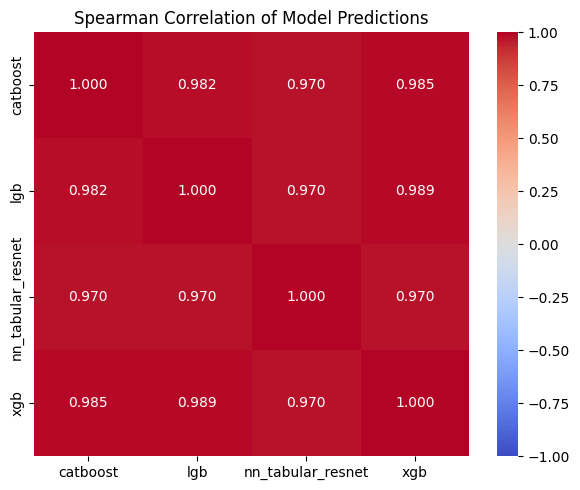

In [11]:
# Build a Spearman correlation matrix of per-model argmax predictions
# to identify near-duplicate models before hill climbing
pred_df = pd.DataFrame(model_preds, index=oof_processed.index)
corr = pred_df.corr(method="spearman")

# Identify near-duplicate models (rho >= threshold)
threshold = 0.995
to_drop_models = set()
corr_cols = sorted(list(corr.columns))

for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        a, b = corr_cols[i], corr_cols[j]
        if a in to_drop_models or b in to_drop_models:
            continue
        if corr.loc[a, b] >= threshold:
            drop = b if model_scores[a] >= model_scores[b] else a
            to_drop_models.add(drop)

if to_drop_models:
    print(f"Dropping {len(to_drop_models)} near-duplicate models (rho >= {threshold}):", sorted(to_drop_models))
    cols_to_drop = []
    for model in to_drop_models:
        cols_to_drop.extend([f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"])
    # Drop from ALL dataframes so hill_climbing and final blend stay consistent
    oof_df        = oof_df.drop(columns=cols_to_drop, errors="ignore")
    test_df       = test_df.drop(columns=cols_to_drop, errors="ignore")
    oof_processed  = oof_processed.drop(columns=cols_to_drop, errors="ignore")
    test_processed = test_processed.drop(columns=cols_to_drop, errors="ignore")
    model_names = [m for m in model_names if m not in to_drop_models]

print("Models remaining after de-dup:", model_names)

display(corr)
plt.figure(figsize=(max(6, len(corr_cols)), max(5, len(corr_cols) - 1)))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f")
plt.title("Spearman Correlation of Model Predictions")
plt.tight_layout()
plt.show()


## Hill Climbing Algorithm

We search for a weighted ensemble that maximizes OOF balanced accuracy. At each iteration we add the single model that most improves the blended balanced accuracy.


In [12]:
# Hill Climbing Algorithm (Caruana-style)
# Iteratively adds the model that maximizes OOF Balanced Accuracy.
def hill_climbing(oof_df: pd.DataFrame, y: np.ndarray, iterations: int = 200, verbose: bool = False):
    model_names = sorted(set([c.split('_prob_')[0] for c in oof_df.columns if '_prob_' in c]))

    model_matrices = {}
    for model in model_names:
        cols = [f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"]
        model_matrices[model] = oof_df[cols].to_numpy(dtype=np.float64)

    # Find the best single model based on Balanced Accuracy
    best_single_model = None
    best_single_score = -np.inf
    for model in model_names:
        preds = np.argmax(model_matrices[model], axis=1)
        score = balanced_accuracy_score(y, preds)
        if score > best_single_score:
            best_single_score = score
            best_single_model = model

    # Initialize with the best single model (float64 to avoid accumulation error)
    current_sum = model_matrices[best_single_model].copy()  # already float64
    k = 1

    model_counts = {m: 0 for m in model_names}
    model_counts[best_single_model] = 1
    history = [best_single_score]

    print(f'Starting Multi-class Hill Climbing for {iterations} iterations...')
    print(f'Starting from: {best_single_model} (Balanced Acc={best_single_score:.6f})')

    for i in range(iterations):
        best_step_score = -np.inf
        best_step_model = None

        for model in model_names:
            # argmax is scale-invariant, so we can skip the /k+1 division
            # (avoids one (N,3) array allocation per candidate per iteration)
            temp_sum = current_sum + model_matrices[model]
            temp_preds = np.argmax(temp_sum, axis=1)
            score = balanced_accuracy_score(y, temp_preds)

            if score > best_step_score:
                best_step_score = score
                best_step_model = model

        current_sum += model_matrices[best_step_model]
        k += 1
        model_counts[best_step_model] += 1
        history.append(best_step_score)

        if verbose and ((i + 1) % 10 == 0):
            print(f'Iter {i+1}: +{best_step_model} -> Balanced Acc {best_step_score:.6f}')

    total = sum(model_counts.values())
    weights = {m: c / total for m, c in model_counts.items() if c > 0}
    return weights, history


In [13]:
# Run hill climbing on rank-normalized, de-duplicated OOF probabilities
weights, history = hill_climbing(oof_processed, y_true_aligned, iterations=500, verbose=True)

print('\nFinal Weights:')
for m, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f'{m}: {w:.4f}')

print(f'\nFinal blended Balanced Acc: {history[-1]:.6f}')


Starting Multi-class Hill Climbing for 500 iterations...
Starting from: xgb (Balanced Acc=0.964794)
Iter 10: +catboost -> Balanced Acc 0.964934
Iter 20: +catboost -> Balanced Acc 0.964932
Iter 30: +catboost -> Balanced Acc 0.964950
Iter 40: +xgb -> Balanced Acc 0.964927
Iter 50: +xgb -> Balanced Acc 0.964930
Iter 60: +xgb -> Balanced Acc 0.964933
Iter 70: +xgb -> Balanced Acc 0.964960
Iter 80: +catboost -> Balanced Acc 0.964946
Iter 90: +nn_tabular_resnet -> Balanced Acc 0.964936
Iter 100: +xgb -> Balanced Acc 0.964964
Iter 110: +nn_tabular_resnet -> Balanced Acc 0.964950
Iter 120: +xgb -> Balanced Acc 0.964965
Iter 130: +catboost -> Balanced Acc 0.964968
Iter 140: +catboost -> Balanced Acc 0.964959
Iter 150: +xgb -> Balanced Acc 0.964967
Iter 160: +catboost -> Balanced Acc 0.964970
Iter 170: +catboost -> Balanced Acc 0.964964
Iter 180: +xgb -> Balanced Acc 0.964967
Iter 190: +xgb -> Balanced Acc 0.964963
Iter 200: +catboost -> Balanced Acc 0.964966
Iter 210: +catboost -> Balanced Acc 

In [14]:
print("OOF columns:", list(oof_df.columns))
print("TEST columns:", list(test_df.columns))

OOF columns: ['catboost_prob_qso', 'catboost_prob_star', 'catboost_prob_galaxy', 'lgb_prob_qso', 'lgb_prob_star', 'lgb_prob_galaxy', 'nn_tabular_resnet_prob_qso', 'nn_tabular_resnet_prob_star', 'nn_tabular_resnet_prob_galaxy', 'xgb_prob_qso', 'xgb_prob_star', 'xgb_prob_galaxy']
TEST columns: ['catboost_prob_qso', 'catboost_prob_star', 'catboost_prob_galaxy', 'lgb_prob_qso', 'lgb_prob_star', 'lgb_prob_galaxy', 'nn_tabular_resnet_prob_qso', 'nn_tabular_resnet_prob_star', 'nn_tabular_resnet_prob_galaxy', 'xgb_prob_qso', 'xgb_prob_star', 'xgb_prob_galaxy']


### Plot Convergence

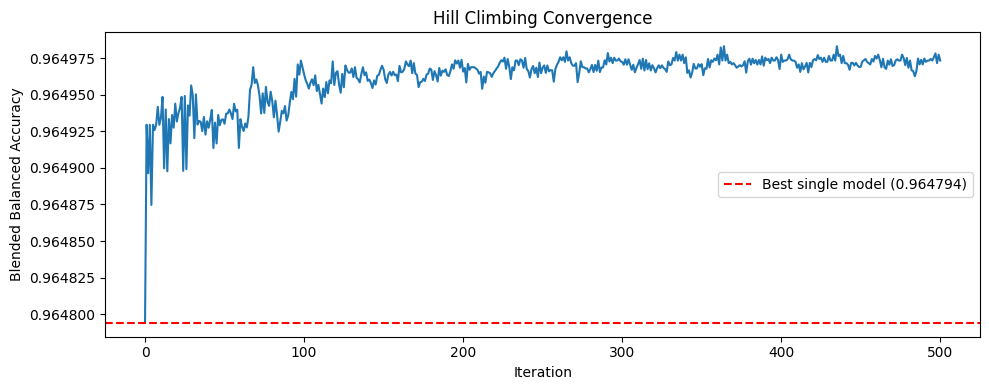

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel('Blended Balanced Accuracy')
plt.title('Hill Climbing Convergence')
plt.axhline(best_single_score, color='red', linestyle='--', label=f'Best single model ({best_single_score:.6f})')
plt.legend()
plt.tight_layout()
plt.show()

### Verify the hill-climbing result is globally optimal

In [16]:
# Grid search to sanity-check hill climbing (exact only for N=4 models)
if len(model_names) == 4:
    best_score, best_w = -np.inf, None
    step = 0.05
    candidates = [round(i * step, 2) for i in range(int(1/step) + 1)]
    m0, m1, m2, m3 = model_names  # dynamic — uses surviving post-dedup names

    for w0, w1, w2 in product(candidates, repeat=3):
        w3 = round(1.0 - w0 - w1 - w2, 2)
        if w3 < 0 or w3 > 1:
            continue
        weights_try = {m0: w0, m1: w1, m2: w2, m3: w3}
        blended = sum(
            oof_processed[[f'{m}_prob_qso', f'{m}_prob_star', f'{m}_prob_galaxy']].to_numpy(dtype=np.float64) * w
            for m, w in weights_try.items()
        )
        score = balanced_accuracy_score(y_true_aligned, np.argmax(blended, axis=1))
        if score > best_score:
            best_score, best_w = score, weights_try.copy()

    print(f'Grid search best: {best_score:.6f} with weights {best_w}')
else:
    print(f'Grid search skipped: only supported for exactly 4 models, found {len(model_names)}.')
    print('Hill climbing result is the primary weight estimate.')


Grid search best: 0.964979 with weights {'catboost': 0.45, 'lgb': 0.0, 'nn_tabular_resnet': 0.05, 'xgb': 0.5}


## Final Ensemble & Submission

We apply the learned weights to both OOF and test probabilities, then write a submission file using the competition’s sample submission schema.


In [17]:
# Blend OOF probabilities using hill-climbing weights (on rank-normalized probs)
blend_oof_probs = np.zeros((len(oof_processed), 3), dtype=np.float64)

for model, w in weights.items():
    cols = [f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"]
    blend_oof_probs += oof_processed[cols].to_numpy(dtype=np.float64) * float(w)

blend_preds = np.argmax(blend_oof_probs, axis=1)
blend_score = balanced_accuracy_score(y_true_aligned, blend_preds)
print(f'Blended OOF Balanced Accuracy: {blend_score:.6f}')


Blended OOF Balanced Accuracy: 0.964973


In [18]:
## Graph Results

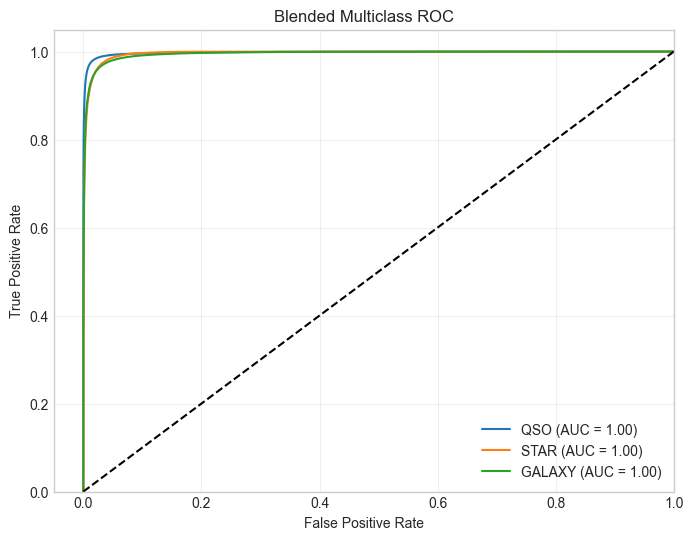

In [19]:
from ps_s06e06_model_visualizer import ModelVisualizer

mviz = ModelVisualizer(model_name='Blended')

class_names = ['QSO (0)', 'STAR (1)', 'GALAXY (2)']

mviz.plot_multiclass_roc_curve(y_true=y_true_aligned, y_score=blend_oof_probs,
                                title='Blended Multiclass ROC')


Normalized confusion matrix


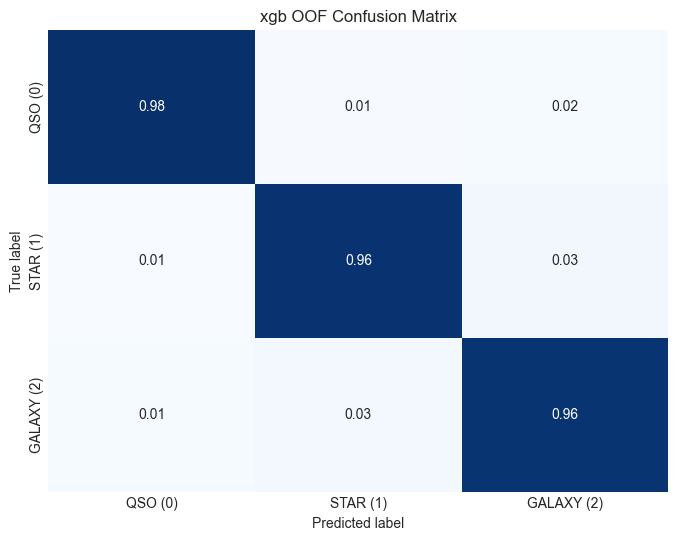

In [20]:
# Best single model vs. blend, side by side
mviz.plot_confusion_matrix(y_true_aligned, model_preds[best_single_model],
                            classes=class_names, normalize=True,
                            title=f'{best_single_model} OOF Confusion Matrix')


Normalized confusion matrix


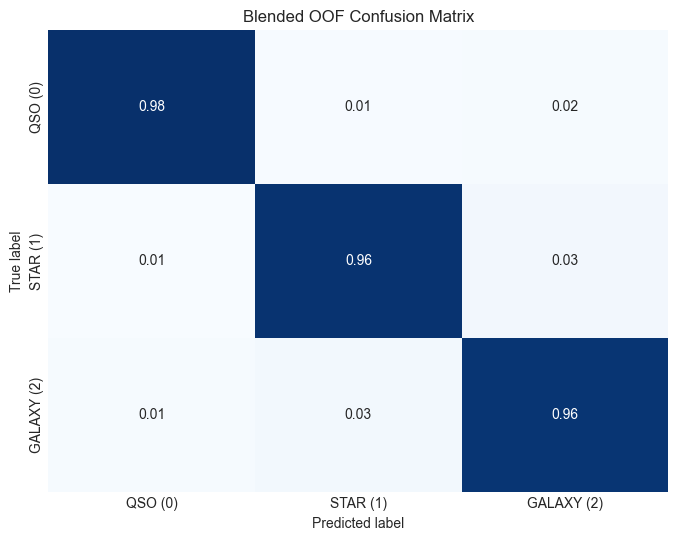

In [21]:
mviz.plot_confusion_matrix(y_true_aligned, blend_preds,
                            classes=class_names, normalize=True,
                            title='Blended OOF Confusion Matrix')


In [22]:
# Blend test probabilities using the same weights and rank-normalized test probs
final_test_probs = np.zeros((len(test_processed), 3), dtype=np.float64)

print('Applying model weights to Test set probabilities...')

for model, weight in weights.items():
    cols = [f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"]
    final_test_probs += test_processed[cols].to_numpy(dtype=np.float64) * float(weight)

final_predictions = np.argmax(final_test_probs, axis=1)

out = submission_df.copy()
out[TARGET] = final_predictions

reverse_mapping = {v: k for k, v in target_mapping.items()}
out[TARGET] = out[TARGET].map(reverse_mapping)

out.to_csv('submission.csv', index=False)
print('\nSaved: submission.csv')

print('\nSUBMISSION PREVIEW')
print('==================')
print(out.head(10))

print('\nPredicted Class Distribution:')
print(out[TARGET].value_counts(normalize=True).sort_index())


Applying model weights to Test set probabilities...

Saved: submission.csv

SUBMISSION PREVIEW
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
5  577352  GALAXY
6  577353  GALAXY
7  577354    STAR
8  577355  GALAXY
9  577356  GALAXY

Predicted Class Distribution:
class
GALAXY   0.634
QSO      0.208
STAR     0.158
Name: proportion, dtype: float64
